In [2]:
import ants
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
seg = ants.image_read('/export/scratch1/PETPAL/sub-VATDYS020/sub-VATDYS020_pet_wm-merged-4d.nii.gz')
pet = ants.image_read('/export/scratch1/PETPAL/sub-VATDYS020/sub-VATDYS020_pet_suvr-pvc.nii.gz')

In [3]:
thal_l = seg[:,:,:,7]
thal_r = seg[:,:,:,37]
thal = thal_l+thal_r

In [4]:
thal_pet = pet.numpy() * thal

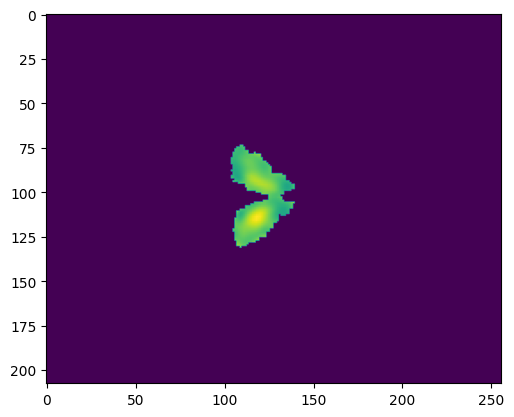

In [5]:
plt.imshow(thal_pet[:,:,120])

In [6]:
thal_pet_mask = thal_pet[np.nonzero(thal_pet)]
np.median(thal_pet_mask)

1.8900588

In [4]:
def get_region_median(
    pet,
    seg_4d,
    regions: list
):
    region = np.zeros(pet.shape)
    for r in regions:
        region += seg_4d[:,:,:,r]
    region_pet = pet.numpy() * region
    region_pet_masked = region_pet[np.nonzero(region_pet)]
    return np.median(region_pet_masked)

In [5]:
get_region_median(pet,seg,[110])

1.5013158321380615

In [6]:
pats = pd.read_csv('cons_names.csv')['participant_id']

In [7]:
critical_regions = [
    [7,37],
    [8,39],
    [9,41],
    [10,44],
    [110],
    [111],
    [112],
    [6,35],
    [5,33]
]

In [8]:
suvrs = np.zeros((len(pats),len(critical_regions)))

In [12]:
for i,pat in enumerate(pats):
    pet_path = os.path.join('/export/scratch1/PETPAL/',pat,f'{pat}_pet_suvr-pvc.nii.gz')
    seg_path = os.path.join('/export/scratch1/PETPAL/',pat,f'{pat}_pet_wm-merged-4d.nii.gz')
    pet = ants.image_read(pet_path)
    seg = ants.image_read(seg_path)
    for j,r in enumerate(critical_regions):
        measure = get_region_median(pet,seg,r)
        suvrs[i,j] = measure

In [13]:
np.savetxt('regional_suvrs.txt',suvrs)

In [14]:
suvrs = np.loadtxt('regional_suvrs.txt')

In [15]:
cd_suvrs = suvrs[:23,:]
hc_suvrs = suvrs[23:,:]

In [16]:
patsrep = sum([9*[pat] for pat in pats],[])

In [17]:
suvr_df = pd.DataFrame()
suvr_df['Group'] = 9*23*['CD']+9*23*['HC']
suvr_df['Region'] = 46*['Thalamus','Caudate','Putamen','Pallidum','Midbrain','Pons','Brainstem','CBM GM','CBM WM']
suvr_df['Subject'] = patsrep
suvr_df['SUVR'] = suvrs.flatten()

In [18]:
suvr_df

,Group,Region,Subject,SUVR
0,CD,Thalamus,sub-VATDYS003,1.840368
1,CD,Caudate,sub-VATDYS003,4.077335
2,CD,Putamen,sub-VATDYS003,5.318639
3,CD,Pallidum,sub-VATDYS003,2.918051
4,CD,Midbrain,sub-VATDYS003,1.391989
...,...,...,...,...
409,HC,Midbrain,sub-PIB20298_ses-VYr0,1.322998
410,HC,Pons,sub-PIB20298_ses-VYr0,1.125456
411,HC,Brainstem,sub-PIB20298_ses-VYr0,1.261267
412,HC,CBM GM,sub-PIB20298_ses-VYr0,1.315555


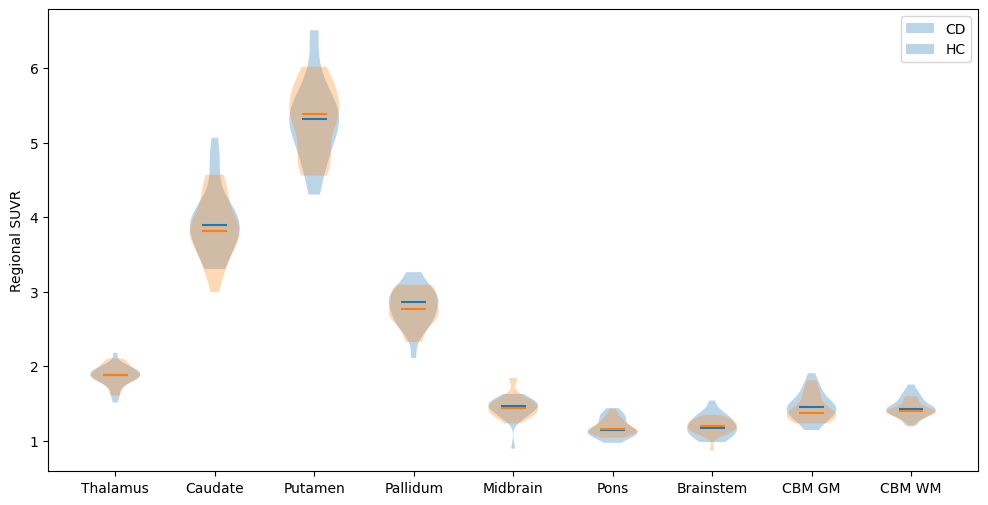

In [19]:
plt.figure(figsize=(12,6))
plt.violinplot(cd_suvrs,showextrema=False,showmedians=True,)
plt.violinplot(hc_suvrs,showextrema=False,showmedians=True)
plt.ylabel('Regional SUVR')
plt.xticks(ticks=range(1,10),labels=['Thalamus','Caudate','Putamen','Pallidum','Midbrain','Pons','Brainstem','CBM GM','CBM WM'])
plt.legend(['CD','HC'])

<Axes: xlabel='Region', ylabel='SUVR'>

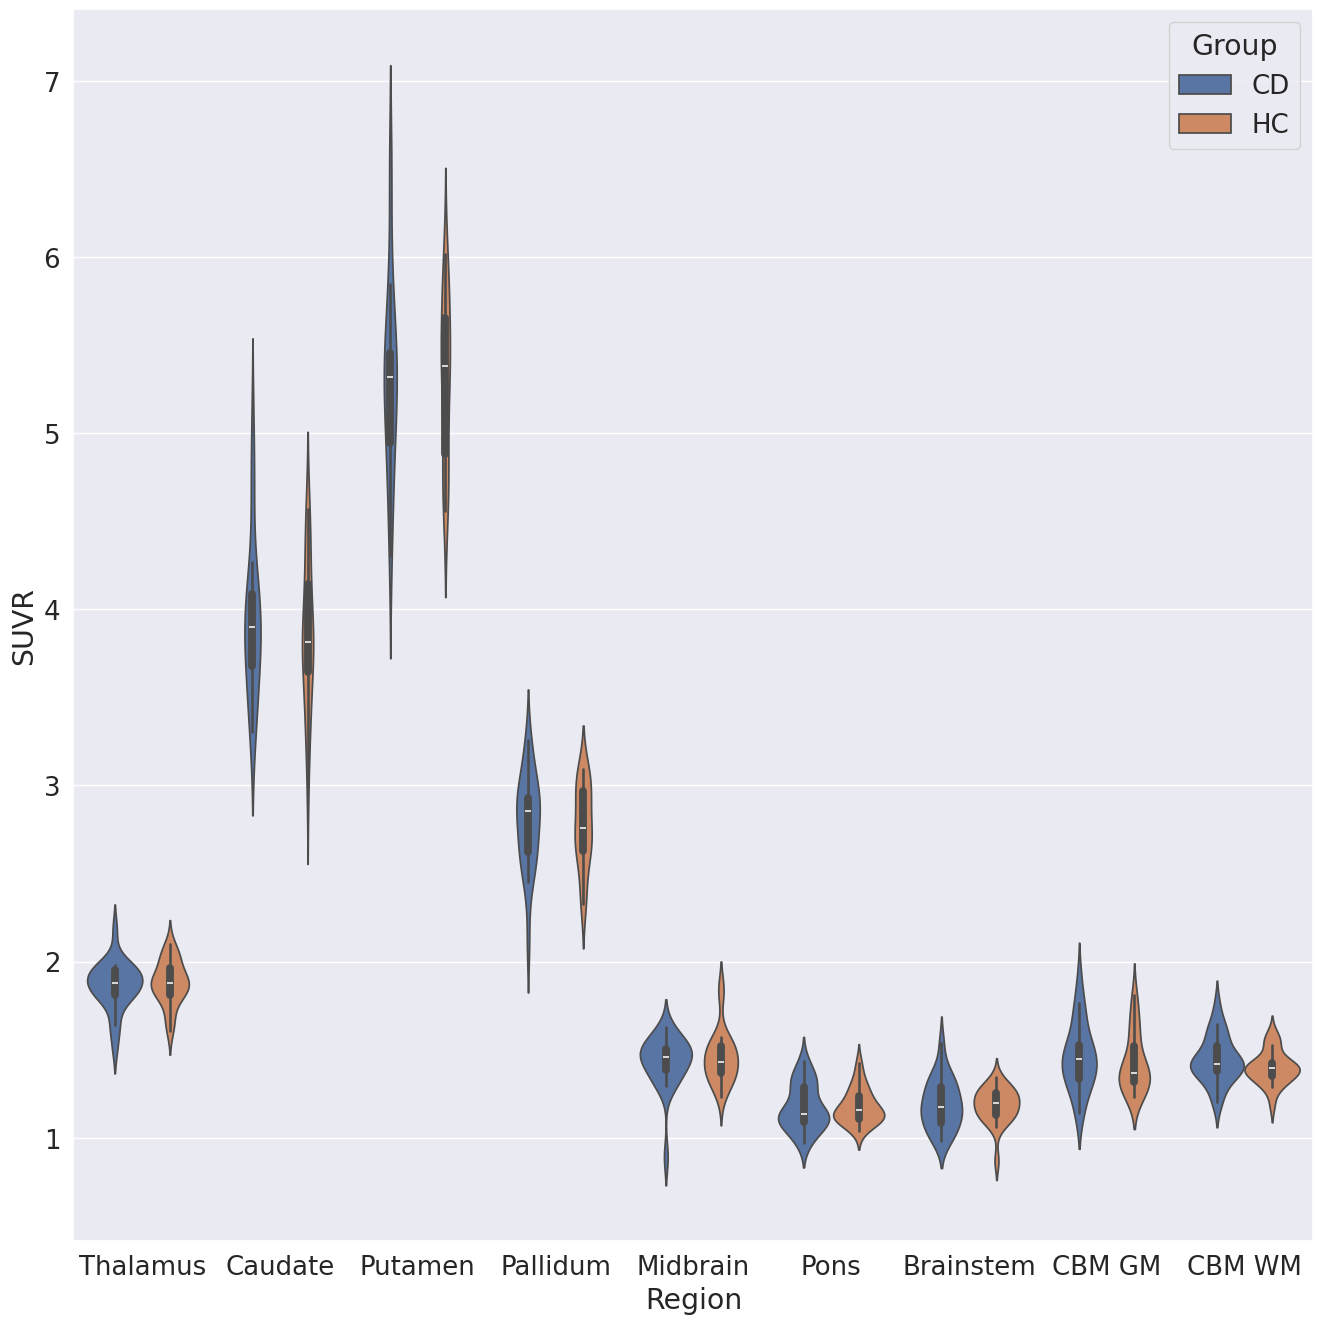

In [20]:
sns.set(rc={'figure.figsize':(16,16)},font_scale=1.7)
sns.violinplot(suvr_df,x='Region',y='SUVR',hue='Group')

Putamen AP

In [9]:
critical_regions = [
    [1],
    [2],
    [3]
]
suvrs = np.zeros((len(pats),len(critical_regions)))
for i,pat in enumerate(pats):
    pet_path = os.path.join('/export/scratch1/PETPAL/',pat,f'{pat}_pet_suvr-pvc_space-atlas.nii.gz')
    seg_path = os.path.join('/data/norris/data1/project/VATDYS/Analyses2024/vatdys_stats/pet/PRISMA_TRIO_PIB_NL_putamen_amp-4d.nii.gz')
    pet = ants.image_read(pet_path)
    seg = ants.image_read(seg_path)
    for j,r in enumerate(critical_regions):
        measure = get_region_median(pet,seg,r)
        suvrs[i,j] = measure
np.savetxt('regional_suvrs.txt',suvrs)
cd_suvrs = suvrs[:23,:]
hc_suvrs = suvrs[23:,:]
patsrep = sum([len(critical_regions)*[pat] for pat in pats],[])
suvr_df = pd.DataFrame()
suvr_df['Group'] = len(critical_regions)*23*['CD']+len(critical_regions)*23*['HC']
suvr_df['Region'] = 46*['Putamen Anterior','Putamen Medial','Putamen Posterior']
suvr_df['Subject'] = patsrep
suvr_df['SUVR'] = suvrs.flatten()

<Axes: xlabel='Region', ylabel='SUVR'>

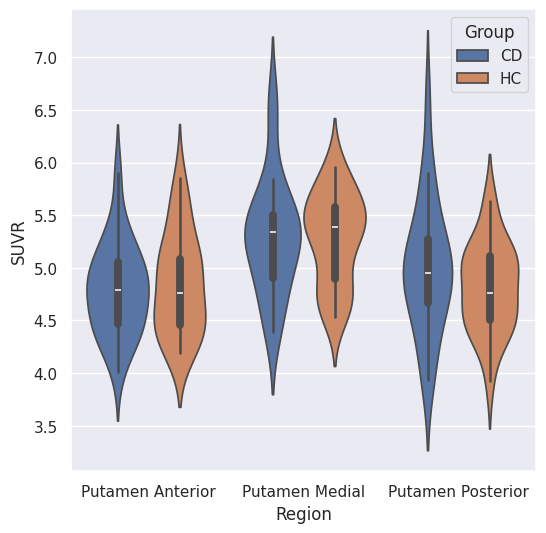

In [10]:

sns.set(rc={'figure.figsize':(6,6)},font_scale=1)
sns.violinplot(suvr_df,x='Region',y='SUVR',hue='Group')

In [28]:
from scipy.stats import ttest_ind

In [17]:
suvr_hc = suvr_df[suvr_df['Group']=='HC'][suvr_df['Region']=='Putamen Posterior']['SUVR']
suvr_cd = suvr_df[suvr_df['Group']=='CD'][suvr_df['Region']=='Putamen Posterior']['SUVR']

/tmp/ipykernel_1799911/3663414985.py:1: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

/tmp/ipykernel_1799911/3663414985.py:2: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



In [31]:
ttest_ind(suvr_cd,suvr_hc,permutations=10000,equal_var=False)

TtestResult(statistic=1.1734617550953084, pvalue=0.2592740725927407, df=nan)